<a href="https://colab.research.google.com/github/rohit-jain8/econ3916-lab05-monte-carlo/blob/main/econ3916_lab05_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Monte Carlo Engine
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 8 min Part 0 + 35 min Core + 15 min Extension

---

**Learning Objectives:**
- Build Monte Carlo simulations from scratch using the NumPy Generator API
- Apply Bayes' Theorem to a real-world screening problem
- Estimate Value at Risk and Expected Shortfall for a portfolio
- Visualize the Law of Large Numbers convergence

**Chapter Reference:** Chapter 5 — Probability and Simulation: From Uncertainty to Decisions

**Foundations First Policy:** Parts 1-3 are GUIDED (run as-is, interpret results). Part 4 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

**Prerequisites:** Part 0 of this lab (below), plus Chapter 5 reading (probability axioms, Bayes' Theorem, Monte Carlo simulation, VaR/ES)

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

---

## Setup

<!-- idiom-note -->
> ### New idiom — NumPy arrays, seeds, and drawing random numbers
>
> **NumPy** gives Python fast numeric arrays. An array looks like a list, but
> arithmetic applies to every element at once — `arr * 2` doubles the whole
> thing with no loop. Nearly every number in this course sits in one
> underneath, including inside pandas.
>
> A **seed** is where the random number generator starts. Randomness here is
> not really random: it is a fixed sequence, and the seed says where to begin.
> That is why a seed sits at the top of every lab — you, your classmate, and
> your grader draw the *same* "random" numbers, so results reproduce. The
> number 42 is a convention, nothing more. You will see two spellings: the
> older `np.random.seed(42)`, and the modern **Generator** form this lab uses,
> `rng = np.random.default_rng(42)`. Prefer the modern one; it is the reason
> every draw below is written `rng.something(...)` rather than
> `np.random.something(...)`.
>
> Two shapes you will read constantly from here on:
>
> ```python
> rng = np.random.default_rng(42)     # a generator, seeded
> rng.normal(0, 1, size=100)          # 100 draws; also .binomial, .poisson, .lognormal
> np.where(cond, a, b)                # "a where cond is True, else b" — for a whole array at once
> ```
>
> `np.where` is an if/else applied to every element simultaneously. It is the
> vectorised version of the one-line `if`/`else` you will meet in Lab 8.


In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Install packages + imports (Google Colab)
# -----------------------------------------------------------
!pip install numpy scipy matplotlib -q

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Modern NumPy Generator API — NOT the legacy np.random.seed()
# This creates an isolated random number generator.
# Changes in one part of your code cannot corrupt randomness in another.
rng = np.random.default_rng(seed=42)

# Clean, publication-ready style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete.")
print(f"NumPy version: {np.__version__}")
print(f"RNG type: {type(rng).__name__}")
print(f"Seed: 42 — all results are reproducible.")

Setup complete.
NumPy version: 2.1.3
RNG type: Generator
Seed: 42 — all results are reproducible.


<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 8 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** NumPy arrays, the random seed, and counting inside a `for` loop.

Everything in this lab rests on random draws, which means it rests on NumPy —
and on reproducibility, which is the difference between a result and an anecdote.


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: NumPy arrays, the seed, and counting in a loop
# -----------------------------------------------------------

# A NUMPY ARRAY is a column of numbers that does arithmetic all at once.
# Everything in this lab is built on them, because simulating means making
# thousands of numbers at a time and pandas is not the right tool for that.
a = np.array([1.0, 2.0, 3.0, 4.0])
print("array:      ", a)
print("a * 2:      ", a * 2)          # applies to every element — no loop
print("mean, std:  ", a.mean(), a.std().round(4))

# THE SEED. Random numbers come from a generator with a starting point. Fix
# the seed and the same "random" numbers come back every run — which is what
# makes a simulation reproducible, and it is why RANDOM_STATE sits at the top
# of every lab in this course.
np.random.seed(42)
first = np.random.normal(0, 1, 3)
np.random.seed(42)
second = np.random.normal(0, 1, 3)
print(f"\nSame seed, same draws: {np.allclose(first, second)}")
print("  ", first.round(4))

# range(n) counts 0, 1, ... n-1. `for _ in range(n)` means "do this n times";
# the underscore is the conventional name for a value you do not need.
# Counting successes in a loop is the shape every simulation in Part 2 uses.
np.random.seed(0)
wins = 0
for _ in range(10_000):
    if np.random.random() < 0.5:      # a fair coin
        wins += 1
print(f"\n10,000 fair coin flips: {wins:,} heads ({wins / 10_000:.1%})")

# Vectorised, the same experiment is one line and far faster. You will see
# both forms in this lab; the loop is for reading, the array is for running.
np.random.seed(0)
flips = np.random.random(10_000) < 0.5
print(f"Same thing, vectorised: {flips.sum():,} heads ({flips.mean():.1%})")

array:       [1. 2. 3. 4.]
a * 2:       [2. 4. 6. 8.]
mean, std:   2.5 1.118

Same seed, same draws: True
   [ 0.4967 -0.1383  0.6477]

10,000 fair coin flips: 5,064 heads (50.6%)
Same thing, vectorised: 5,064 heads (50.6%)


---

## Part 1: Coin Flip Convergence — The Law of Large Numbers (GUIDED — 9 min)

The **Law of Large Numbers (LLN)** guarantees that as the number of independent trials grows, the sample mean converges to the expected value. This is *why* Monte Carlo simulation works.

We start with the simplest possible simulation: fair coin flips. The true probability of heads is 0.5. How many flips does it take for the running proportion to stabilize near 0.5?

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Simulate 10,000 fair coin flips
# -----------------------------------------------------------
n_flips = 10_000

# Bernoulli trial: 1 = heads, 0 = tails, p = 0.5
flips = rng.binomial(n=1, p=0.5, size=n_flips)

# Running proportion of heads after each flip
cumulative_heads = np.cumsum(flips)
flip_number = np.arange(1, n_flips + 1)
running_proportion = cumulative_heads / flip_number

print(f"Total flips: {n_flips:,}")
print(f"Total heads: {flips.sum():,} ({flips.mean():.4f})")
print(f"")
print(f"Running proportion at key milestones:")
for n in [10, 50, 100, 500, 1000, 5000, 10000]:
    print(f"  After {n:>6,} flips: {running_proportion[n-1]:.4f}")

Total flips: 10,000
Total heads: 4,985 (0.4985)

Running proportion at key milestones:
  After     10 flips: 0.6000
  After     50 flips: 0.5000
  After    100 flips: 0.4700
  After    500 flips: 0.5020
  After  1,000 flips: 0.4970
  After  5,000 flips: 0.4910
  After 10,000 flips: 0.4985


**Expected output:** The proportion starts noisy (could be 0.60 or 0.40 after 10 flips) and gradually tightens around 0.50. By 10,000 flips, the proportion should be within 0.01 of the true value.

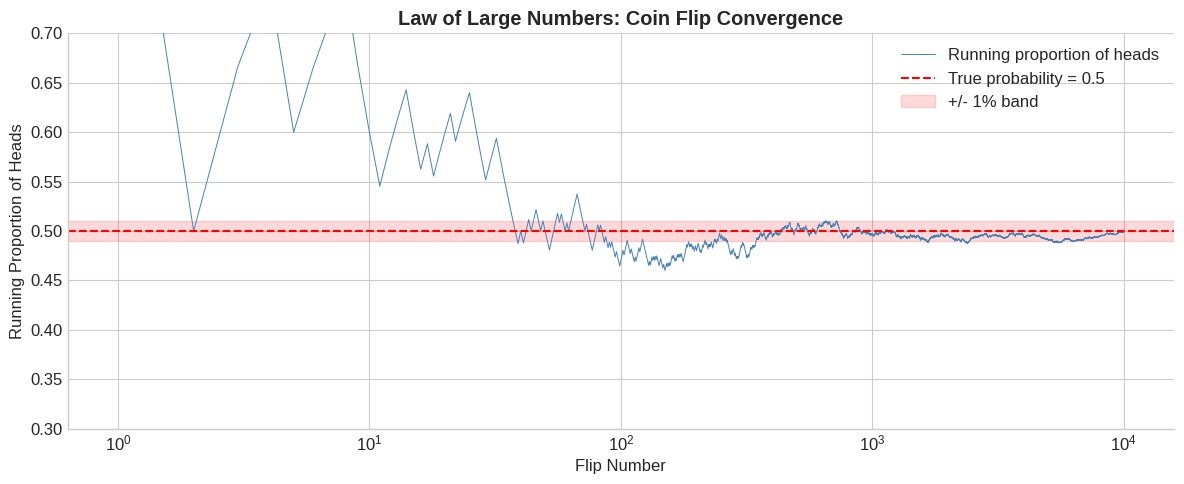


The running proportion stays within 1% of 0.5 from flip 6,455 onward.


In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Plot LLN convergence
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(flip_number, running_proportion, linewidth=0.7, color="steelblue",
        label="Running proportion of heads")
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1.5,
           label="True probability = 0.5")

# Shade the +/- 1% band around 0.5
ax.axhspan(0.49, 0.51, alpha=0.15, color="red", label="+/- 1% band")

ax.set_xlabel("Flip Number")
ax.set_ylabel("Running Proportion of Heads")
ax.set_title("Law of Large Numbers: Coin Flip Convergence", fontweight="bold")
ax.set_xscale("log")
ax.set_ylim(0.3, 0.7)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Find when the running proportion first stays within 1% of 0.5
within_band = np.abs(running_proportion - 0.5) <= 0.01
# Find the last time it leaves the band, then the next entry is "stable"
outside_indices = np.where(~within_band)[0]
if len(outside_indices) > 0:
    stable_from = outside_indices[-1] + 2  # +2 because 0-indexed and we want the next flip
    print(f"\nThe running proportion stays within 1% of 0.5 from flip {stable_from:,} onward.")
else:
    print(f"\nThe running proportion stays within 1% of 0.5 from the beginning.")

### Interpretation Questions

**Q1:** At approximately what sample size does the running proportion stay within 1% of 0.5? What does this tell you about the minimum number of observations you need before trusting a sample proportion?

**Q2:** If this were a poll instead of a coin flip (e.g., proportion of voters supporting a candidate), what would LLN imply about the minimum sample size for a reliable poll?

**Q3:** (Callback to Ch 4) The sample mean of a Bernoulli trial *is* the sample proportion. Is this sample mean robust or non-robust? Why does LLN still work despite the mean's sensitivity to outliers?

*Your answers here:*

1. The running proportion stays within 1% of 0.5 starting at around 6,455 flips. This shows that it can take a pretty large number of observations before the sample proportion consistently stays close to the true proportion. Based on this simulation, I would want a fairly large sample before really trusting the sample proportion.
2. If this were a poll, the LLN would tell us that having a larger sample size should give us a more reliable estimate of the true proportion of voters who support a candidate. It does not necessarily mean that we would need exactly 6,455 people, but in general, the more people we poll, the more we can trust that the sample proportion is close to the true population proportion.
3. The sample mean is non-robust because means can normally be affected a lot by extreme values or outliers. However, with a Bernoulli trial, every observation can only be either 0 or 1, so there really cannot be any extreme outliers. Because of this, as we get more and more observations, the random differences start to average out and the sample proportion gets closer to the true probability.

---

## Part 2: Monty Hall Simulation (GUIDED + YOUR TASK — 8 min)

The **Monty Hall Problem:** You are on a game show. Three doors: one hides a car, two hide goats. You pick a door. The host (who knows what is behind each door) opens a different door, always revealing a goat. Should you switch or stay?

Intuition says it should not matter. Conditional probability says otherwise. Let's simulate 10,000 games and find out.

In [5]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Monty Hall — "always stay" strategy
# -----------------------------------------------------------
n_games = 10_000

# Car is behind a random door (0, 1, or 2) for each game
car_door = rng.integers(0, 3, size=n_games)

# Player always picks door 0 (without loss of generality)
player_choice = np.zeros(n_games, dtype=int)

# "Always stay" strategy: win if car is behind door 0
stay_wins = (car_door == player_choice).sum()

print(f"Strategy: ALWAYS STAY")
print(f"Wins: {stay_wins:,} out of {n_games:,}")
print(f"Win rate: {stay_wins / n_games:.4f}")
print(f"Expected (theoretical): 0.3333")

Strategy: ALWAYS STAY
Wins: 3,306 out of 10,000
Win rate: 0.3306
Expected (theoretical): 0.3333


In [6]:
# -----------------------------------------------------------
# YOUR TASK — Fill in the blanks
# Step 4: Monty Hall — "always switch" strategy
# -----------------------------------------------------------

switch_wins = 0

for i in range(n_games):
    car = car_door[i]         # Where the car actually is
    player = player_choice[i] # Player's initial pick (always 0)

    # Host opens a door that is:
    #   (a) not the player's choice
    #   (b) not the car door
    # This is the conditional probability step — the host's action
    # gives you information.
    available_to_host = [d for d in range(3) if d != player and d != car]
    host_opens = rng.choice(available_to_host)

    # Player switches to the remaining door
    # FILL IN: the switched door is the one that is NOT player and NOT host_opens
    switched_door = [d for d in range(3) if d != player and d != host_opens][0] # Hint: [d for d in range(3) if d != player and d != host_opens][0]

    # FILL IN: count a win if the switched door has the car
    if switched_door == car: # Hint: compare switched_door to car
        switch_wins += 1

print(f"Strategy: ALWAYS SWITCH")
print(f"Wins: {switch_wins:,} out of {n_games:,}")
print(f"Win rate: {switch_wins / n_games:.4f}")
print(f"Expected (theoretical): 0.6667")
# Expected output: Win rate ~0.6667

Strategy: ALWAYS SWITCH
Wins: 6,694 out of 10,000
Win rate: 0.6694
Expected (theoretical): 0.6667


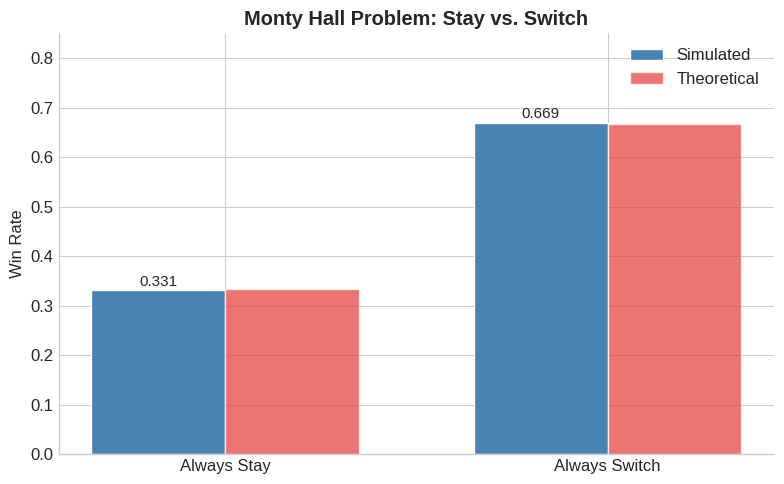


Switching wins 2.0x more often than staying.


In [7]:
# -----------------------------------------------------------
# GUIDED — Run as-is (after completing the blanks above)
# Step 5: Compare the two strategies visually
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ["Always Stay", "Always Switch"]
win_rates = [stay_wins / n_games, switch_wins / n_games]
theoretical = [1/3, 2/3]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, win_rates, width, label="Simulated",
               color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, theoretical, width, label="Theoretical",
               color="#E53935", alpha=0.7, edgecolor="white")

ax.set_ylabel("Win Rate")
ax.set_title("Monty Hall Problem: Stay vs. Switch", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(0, 0.85)

# Annotate bars
for bar, val in zip(bars1, win_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nSwitching wins {switch_wins / n_games / (stay_wins / n_games):.1f}x more often than staying.")

### Interpretation Questions

**Q1:** Why is switching optimal? Connect your answer to *conditional probability* — what information does the host's action give you?

**Q2:** Many people (including PhD mathematicians!) initially believe switching does not help. Why is this problem so counterintuitive? What assumption does your intuition make that is wrong?

**Q3:** If the host opened a door *at random* (possibly revealing the car), would switching still be optimal? Why or why not?

*Your answers here:*

1. Switching is better because there is only a 1/3 chance that I picked the right door originally, meaning there is a 2/3 chance the car is behind one of the other two doors. When the host opens one of those doors, they already know it does not have the car behind it. This gives me more information, since that 2/3 chance is now basically on the one other unopened door. This matches our simulation, where switching won about 67% of the time compared to about 33% for staying.
2. I think this is so counterintuitive because once one door is opened, it seems like there are only two choices left and it should just be 50/50. The issue with that thinking is that the host is not choosing a door randomly. They know where the car is and purposely open a door without it. Because of that, the door they open actually gives us information, which is why the two remaining doors do not each have the same probability.
3. If the host was just opening a door at random, then switching would not have the same advantage. The whole reason switching works is because the host knows where the car is and purposely opens a door that does not have it. If they were choosing randomly, they could even accidentally reveal the car. If they randomly opened a door and it happened to have a goat, then the two unopened doors would have the same chance of having the car, so there would not really be an advantage to switching.

---

## Part 3: Bayes' Theorem — Disease Screening (GUIDED — 8 min)

A medical screening test has:
- **Prevalence** (base rate): 1% of the population has the disease
- **Sensitivity**: 95% (test correctly detects 95% of sick people)
- **Specificity**: 90% (test correctly clears 90% of healthy people)

You test positive. What is the probability you are actually sick?

Most people guess 90-95%. Bayes' Theorem says otherwise.

In [11]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 6: Bayes' Theorem — analytical calculation
# -----------------------------------------------------------
prevalence = 0.10       # P(Sick)
sensitivity = 0.95      # P(Positive | Sick)
specificity = 0.90      # P(Negative | Healthy)
false_positive_rate = 1 - specificity  # P(Positive | Healthy) = 0.10

# Step 1: Total probability of testing positive
p_positive = (sensitivity * prevalence) + (false_positive_rate * (1 - prevalence))

# Step 2: Bayes' Theorem — P(Sick | Positive)
posterior = (sensitivity * prevalence) / p_positive

print(f"Bayes' Theorem: Disease Screening")
print(f"{'='*50}")
print(f"")
print(f"Given:")
print(f"  P(Sick)               = {prevalence:.4f}  (prevalence)")
print(f"  P(Positive | Sick)    = {sensitivity:.4f}  (sensitivity)")
print(f"  P(Positive | Healthy) = {false_positive_rate:.4f}  (false positive rate)")
print(f"")
print(f"Step 1: P(Positive) = {sensitivity}*{prevalence} + {false_positive_rate:.4f}*{1-prevalence}")
print(f"                    = {sensitivity*prevalence:.4f} + {false_positive_rate*(1-prevalence):.4f}")
print(f"                    = {p_positive:.4f}")
print(f"")
print(f"Step 2: P(Sick | Positive) = ({sensitivity} * {prevalence}) / {p_positive:.4f}")
print(f"                           = {sensitivity*prevalence:.4f} / {p_positive:.4f}")
print(f"                           = {posterior:.4f}")
print(f"")
print(f"Result: Only {posterior:.1%} of positive tests are truly sick.")
print(f"The other {1-posterior:.1%} are FALSE POSITIVES.")

Bayes' Theorem: Disease Screening

Given:
  P(Sick)               = 0.1000  (prevalence)
  P(Positive | Sick)    = 0.9500  (sensitivity)
  P(Positive | Healthy) = 0.1000  (false positive rate)

Step 1: P(Positive) = 0.95*0.1 + 0.1000*0.9
                    = 0.0950 + 0.0900
                    = 0.1850

Step 2: P(Sick | Positive) = (0.95 * 0.1) / 0.1850
                           = 0.0950 / 0.1850
                           = 0.5135

Result: Only 51.4% of positive tests are truly sick.
The other 48.6% are FALSE POSITIVES.


**Expected output:** P(Sick | Positive) is approximately 0.0876 (8.8%). A "95% accurate" test produces ~91% false positives when the disease is rare. This is the **base rate fallacy** from Chapter 5.

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 7: Simulate 100,000 people to verify Bayes' Theorem
# -----------------------------------------------------------
n_people = 100_000

# Step A: Determine who is actually sick (1% prevalence)
is_sick = rng.random(n_people) < prevalence

# Step B: Generate test results
# Sick people: test positive with probability = sensitivity
# Healthy people: test positive with probability = false_positive_rate
test_positive = np.where(
    is_sick,
    rng.random(n_people) < sensitivity,
    rng.random(n_people) < false_positive_rate
)

# Step C: Among those who tested positive, how many are actually sick?
true_positives = (test_positive & is_sick).sum()
total_positives = test_positive.sum()
simulated_posterior = true_positives / total_positives

print(f"Simulation: {n_people:,} people tested")
print(f"{'='*50}")
print(f"Actually sick:          {is_sick.sum():>7,} ({is_sick.mean():.2%})")
print(f"Tested positive:        {total_positives:>7,} ({test_positive.mean():.2%})")
print(f"True positives:         {true_positives:>7,}")
print(f"False positives:        {total_positives - true_positives:>7,}")
print(f"")
print(f"Simulated P(Sick | Positive): {simulated_posterior:.4f}")
print(f"Analytical P(Sick | Positive): {posterior:.4f}")
print(f"Difference: {abs(simulated_posterior - posterior):.4f}")

Simulation: 100,000 people tested
Actually sick:            1,058 (1.06%)
Tested positive:         10,847 (10.85%)
True positives:             997
False positives:          9,850

Simulated P(Sick | Positive): 0.0919
Analytical P(Sick | Positive): 0.0876
Difference: 0.0044


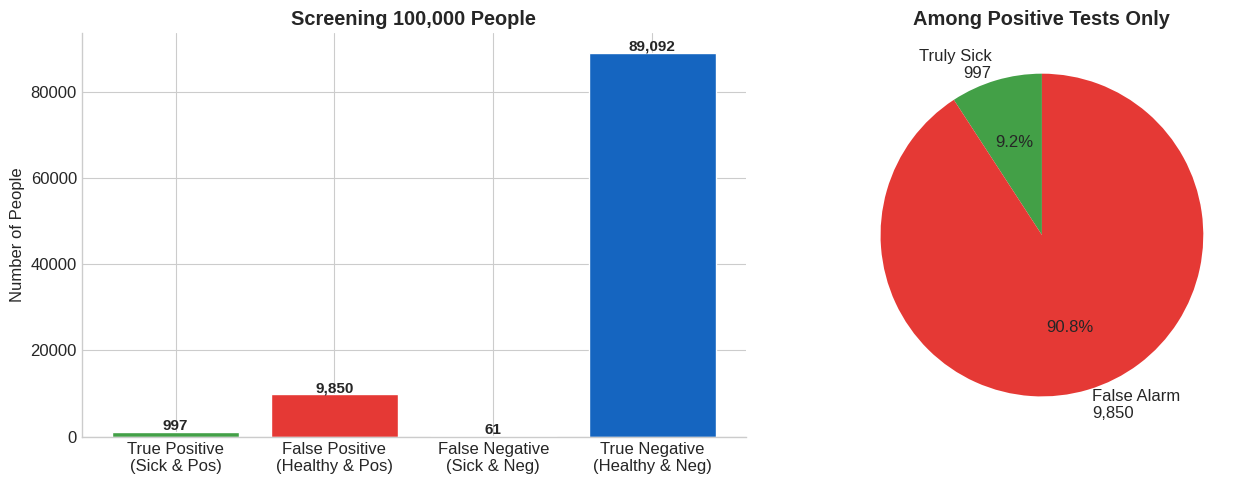


The pie chart shows: of everyone who tested positive,
only 9.2% are actually sick.
The rest are false alarms — the base rate fallacy in action.


In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 8: Visualize the confusion matrix as a mosaic
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Natural frequency breakdown
ax = axes[0]
categories = ["True Positive\n(Sick & Pos)", "False Positive\n(Healthy & Pos)",
              "False Negative\n(Sick & Neg)", "True Negative\n(Healthy & Neg)"]
counts = [
    (test_positive & is_sick).sum(),
    (test_positive & ~is_sick).sum(),
    (~test_positive & is_sick).sum(),
    (~test_positive & ~is_sick).sum()
]
colors = ["#43A047", "#E53935", "#FF9800", "#1565C0"]
bars = ax.bar(categories, counts, color=colors, edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{count:,}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of People")
ax.set_title("Screening 100,000 People", fontweight="bold")

# Panel B: Among positive tests only
ax = axes[1]
positive_breakdown = [true_positives, total_positives - true_positives]
labels_pos = [f"Truly Sick\n{true_positives:,}",
              f"False Alarm\n{total_positives - true_positives:,}"]
ax.pie(positive_breakdown, labels=labels_pos, colors=["#43A047", "#E53935"],
       autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
ax.set_title("Among Positive Tests Only", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nThe pie chart shows: of everyone who tested positive,")
print(f"only {simulated_posterior:.1%} are actually sick.")
print(f"The rest are false alarms — the base rate fallacy in action.")

### Interpretation Questions

**Q1:** A positive test result means... what probability of actually being sick? Why is this so much lower than the test's 95% sensitivity?

**Q2:** If the prevalence were 10% instead of 1%, how would the posterior change? Would the test be more or less useful? (Try changing `prevalence = 0.10` above and re-running.)

**Q3:** A politician says: "This test is 95% accurate, so if you test positive, you are almost certainly sick." Write a one-sentence correction for a newspaper editorial, using the numbers from this simulation.

*Your answers here:*

1. A positive test result means there is only about an 8.8% chance of actually being sick based on the calculation, or about 9.2% in our simulation. This is so much lower than the 95% sensitivity because only 1% of the population actually has the disease to begin with. Since there are so many more healthy people being tested, even the 10% false positive rate creates a lot of false positives. In our simulation, there were 9,850 false positives compared to only 997 true positives.
2. If the prevalence increases from 1% to 10%, the probability of actually being sick after testing positive increases a lot, from about 8.8% to 51.4%. This makes the test more useful because when the disease is more common in the population, a positive result is much more likely to be a true positive rather than a false positive.
3. Even though the test has 95% sensitivity, our simulation shows that with only 1% of the population being sick, only about 9.2% of people who tested positive were actually sick, while the other 90.8% were false positives.

---

## Part 4: Monte Carlo Value at Risk (YOUR TASK — 10 min)

**Value at Risk (VaR)** answers: "What is the maximum daily loss I can expect at a given confidence level?" **Expected Shortfall (ES)** answers: "If things go badly, how bad on average?"

Basel III (January 2025) replaced VaR with ES as the global regulatory standard for bank risk measurement, because VaR ignores how severe the worst losses are.

Your task: generate simulated portfolio returns, compute risk measures, and visualize them.

In [12]:
# -----------------------------------------------------------
# YOUR TASK — Fill in the blanks
# Step 9: Generate simulated daily portfolio returns
# -----------------------------------------------------------

# Portfolio assumptions (typical equity portfolio):
#   Mean daily return:  0.04% (about 10% annualized)
#   Std of daily return: 1.2% (about 19% annualized)

n_days = 10_000
mu = 0.0004    # mean daily return
sigma = 0.012  # std of daily return

# FILL IN: generate n_days daily returns from a Normal distribution
# Hint: use rng.normal(loc=____, scale=____, size=____)
daily_returns = rng.normal(loc=mu, scale=sigma, size=n_days)

print(f"Simulated {n_days:,} daily returns")
print(f"Sample mean:  {daily_returns.mean():.6f} (target: {mu})")
print(f"Sample std:   {daily_returns.std():.6f} (target: {sigma})")
print(f"Min return:   {daily_returns.min():.4f} ({daily_returns.min()*100:.2f}%)")
print(f"Max return:   {daily_returns.max():.4f} ({daily_returns.max()*100:.2f}%)")
# Expected: mean close to 0.0004, std close to 0.012

Simulated 10,000 daily returns
Sample mean:  0.000273 (target: 0.0004)
Sample std:   0.011897 (target: 0.012)
Min return:   -0.0429 (-4.29%)
Max return:   0.0426 (4.26%)


In [13]:
# -----------------------------------------------------------
# YOUR TASK — Fill in the blanks
# Step 10: Calculate VaR and Expected Shortfall
# -----------------------------------------------------------

# VaR at 95% confidence = negative of the 5th percentile of returns
# VaR at 99% confidence = negative of the 1st percentile of returns

# FILL IN: compute the 5th and 1st percentiles
# Hint: use np.percentile(daily_returns, ____)
var_95 = -np.percentile(daily_returns, 5) # 5th percentile
var_99 = -np.percentile(daily_returns, 1) # 1st percentile

# Expected Shortfall: average of all losses BEYOND VaR
# FILL IN: select returns that are worse than (less than) -VaR
tail_95 = daily_returns[daily_returns <= -var_95]  # Hint: the cutoff is -var_95
es_95 = -tail_95.mean()

tail_99 = daily_returns[daily_returns <= -var_99]
es_99 = -tail_99.mean()

# Scale to a $1,000,000 portfolio
portfolio_value = 1_000_000

print(f"Risk Measures (daily, ${portfolio_value:,.0f} portfolio)")
print(f"{'='*50}")
print(f"{'Measure':<20} {'Percentage':>12} {'Dollar Loss':>15}")
print(f"{'-'*50}")
print(f"{'95% VaR':<20} {var_95:>11.4%} ${var_95 * portfolio_value:>14,.0f}")
print(f"{'95% ES':<20} {es_95:>11.4%} ${es_95 * portfolio_value:>14,.0f}")
print(f"{'99% VaR':<20} {var_99:>11.4%} ${var_99 * portfolio_value:>14,.0f}")
print(f"{'99% ES':<20} {es_99:>11.4%} ${es_99 * portfolio_value:>14,.0f}")
# Expected: 95% VaR ~ $19,000-$20,000, 95% ES ~ $24,000-$25,000

Risk Measures (daily, $1,000,000 portfolio)
Measure                Percentage     Dollar Loss
--------------------------------------------------
95% VaR                  1.9494% $        19,494
95% ES                   2.4230% $        24,230
99% VaR                  2.7046% $        27,046
99% ES                   3.1221% $        31,221


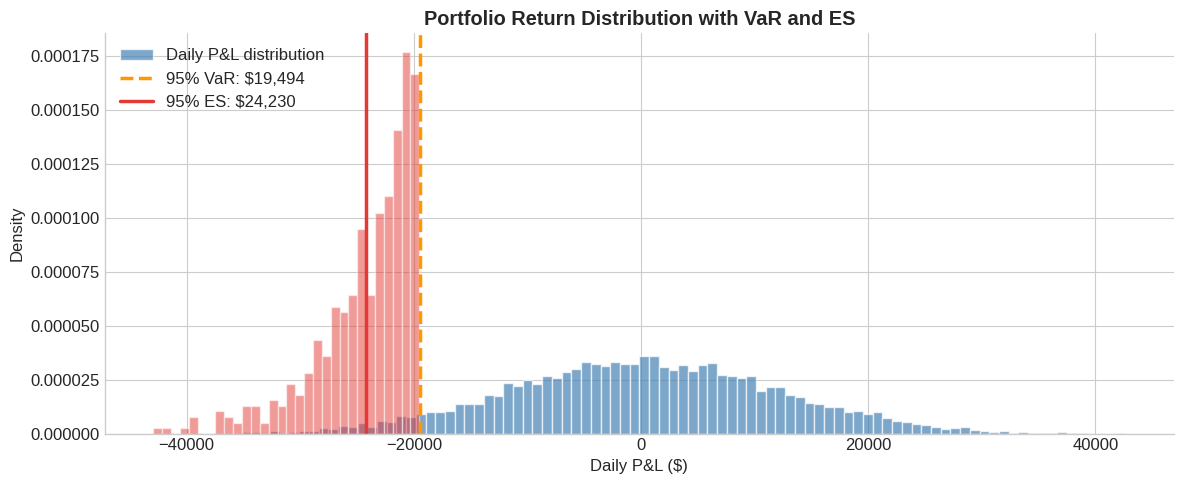


VaR says: 'On 95% of days, you won't lose more than $19,494.'
ES  says: 'On the worst 5% of days, you'll lose $24,230 on average.'

ES is always larger than VaR — it captures tail severity.
This is why Basel III replaced VaR with ES in January 2025.


In [14]:
# -----------------------------------------------------------
# GUIDED — Run as-is (after completing the blanks above)
# Step 11: Visualize the return distribution with VaR and ES lines
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Convert returns to dollar P&L
pnl = daily_returns * portfolio_value

ax.hist(pnl, bins=100, density=True, color="steelblue", alpha=0.7,
        edgecolor="white", label="Daily P&L distribution")

# VaR line
ax.axvline(-var_95 * portfolio_value, color="#FF9800", linewidth=2.5,
           linestyle="--", label=f"95% VaR: ${var_95 * portfolio_value:,.0f}")

# ES line
ax.axvline(-es_95 * portfolio_value, color="#E53935", linewidth=2.5,
           linestyle="-", label=f"95% ES: ${es_95 * portfolio_value:,.0f}")

# Shade the tail beyond VaR
tail_pnl = pnl[pnl <= -var_95 * portfolio_value]
ax.hist(tail_pnl, bins=30, density=True, color="#E53935", alpha=0.5,
        edgecolor="white")

ax.set_xlabel("Daily P&L ($)")
ax.set_ylabel("Density")
ax.set_title("Portfolio Return Distribution with VaR and ES", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"\nVaR says: 'On 95% of days, you won't lose more than ${var_95 * portfolio_value:,.0f}.'")
print(f"ES  says: 'On the worst 5% of days, you'll lose ${es_95 * portfolio_value:,.0f} on average.'")
print(f"\nES is always larger than VaR — it captures tail severity.")
print(f"This is why Basel III replaced VaR with ES in January 2025.")

### Interpretation Questions

**Q1:** On a $1,000,000 portfolio, what is the maximum daily loss you would expect 95% of the time? Express your answer as a dollar amount.

**Q2:** ES is always larger than VaR. Why? What does ES capture that VaR misses?

**Q3:** We assumed returns follow a Normal distribution. Chapter 5 showed that real financial returns have fat tails (the S&P 500 has experienced 5%+ daily drops far more often than the Normal predicts). How would fat tails change the VaR and ES estimates — would they be higher or lower than what we computed?

**Q4:** A risk manager reports: "Take the 99% VaR your own Step 21 printed." A board member responds: "Great, so our maximum loss is $28,000." What is wrong with this interpretation?

*Your answers here:*

1. On a 1,000,000 dollar portfolio, the maximum daily loss we would expect 95% of the time is about 19,494 dollars. Basically, this means that on 95% of days, we would not expect to lose more than 19,494 dollars.
2. ES is larger than VaR because VaR only tells us the loss at a certain cutoff, while ES looks at the losses that happen beyond that cutoff. It basically tells us how bad our losses are on average during the worst days. In our simulation, the 95% VaR was 19,494 dollars, while the 95% ES was higher at 24,230 dollars.
3. If financial returns actually have fatter tails than a Normal distribution, then our VaR and ES estimates would both be higher. This is because really large losses would happen more often than our Normal distribution assumes, meaning our current simulation is probably underestimating some of the risk.
4. The 99% VaR of about 27,046 dollars does not mean that 27,046 dollars is the most we could possibly lose. It just means that we would expect our loss to stay below that amount on 99% of days. There is still that other 1% of days where we could lose more than 27,046 dollars, and potentially by a pretty large amount.

---

## Extension: Monte Carlo Convergence Rate (Optional — 15 min)

Chapter 5 stated that Monte Carlo error decreases at $O(1/\sqrt{n})$. Let's verify this empirically using the classic pi estimation problem.

**The idea:** Drop random points in a unit square. The fraction landing inside the inscribed quarter-circle converges to $\pi/4$. We measure the estimation error at different sample sizes and check that it follows the $1/\sqrt{n}$ rate on a log-log plot.

In [ ]:
# -----------------------------------------------------------
# EXTENSION — Run as-is
# Step 12: Estimate pi at multiple sample sizes
# -----------------------------------------------------------
sample_sizes = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
n_trials = 50  # repeat each sample size 50 times to get average error

results = []

for n in sample_sizes:
    errors = []
    for trial in range(n_trials):
        # Use a different seed for each trial (but reproducible)
        trial_rng = np.random.default_rng(seed=trial * 1000 + n)
        x = trial_rng.uniform(0, 1, n)
        y = trial_rng.uniform(0, 1, n)
        inside = (x**2 + y**2) <= 1.0
        pi_est = 4 * inside.mean()
        errors.append(abs(pi_est - np.pi))

    avg_error = np.mean(errors)
    results.append({"n": n, "avg_error": avg_error})
    print(f"n = {n:>7,}  |  Avg |error| = {avg_error:.6f}  |  1/sqrt(n) = {1/np.sqrt(n):.6f}")

print(f"\nIf error ~ 1/sqrt(n), then doubling n should reduce error by ~29%.")
print(f"To halve the error, you need 4x the samples.")

In [ ]:
# -----------------------------------------------------------
# EXTENSION — Run as-is
# Step 13: Log-log plot to verify O(1/sqrt(n)) convergence
# -----------------------------------------------------------
ns = np.array([r["n"] for r in results])
errs = np.array([r["avg_error"] for r in results])

fig, ax = plt.subplots(figsize=(10, 6))

# Actual errors
ax.loglog(ns, errs, "o-", color="steelblue", linewidth=2, markersize=8,
          label="Monte Carlo error (average of 50 trials)")

# Theoretical 1/sqrt(n) reference line (scaled to match)
scale = errs[0] * np.sqrt(ns[0])  # calibrate to first point
theoretical = scale / np.sqrt(ns)
ax.loglog(ns, theoretical, "--", color="#E53935", linewidth=2,
          label=r"Reference: $O(1/\sqrt{n})$")

ax.set_xlabel("Number of Samples (n)", fontsize=13)
ax.set_ylabel("Average Absolute Error", fontsize=13)
ax.set_title(r"Monte Carlo Convergence: Error $\propto 1/\sqrt{n}$",
             fontweight="bold", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Verify slope on log-log scale (should be approximately -0.5)
log_ns = np.log10(ns)
log_errs = np.log10(errs)
slope = np.polyfit(log_ns, log_errs, 1)[0]
print(f"\nLog-log slope: {slope:.3f}")
print(f"Expected slope: -0.500 (if error ~ 1/sqrt(n))")
print(f"\nThis confirms the O(1/sqrt(n)) convergence rate.")
print(f"Implication: to halve your Monte Carlo error, quadruple your samples.")

### Extension Interpretation

**Q1:** The log-log slope should be approximately -0.5. What does this tell you about the relationship between computational cost and accuracy in Monte Carlo simulation?

**Q2:** The Fed uses 250,000 Monte Carlo draws for stress tests. Based on the convergence rate, how much more accurate is this compared to using 10,000 draws?

*Your answers here:*

1.
2.

---
## AI-Assisted Expansion: Monte Carlo Playground

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over Monte Carlo simulation, the Law of Large Numbers, Bayes' Theorem, and Value at Risk. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive playground (ipywidgets + matplotlib, running inside Colab) that lets the user:
1. Set the number of simulations and watch a running average settle toward its true value
2. Move a disease-prevalence slider and see the chance that a positive test means the person is sick
3. Set the mean return, volatility and portfolio value and read 95% and 99% VaR and Expected Shortfall in dollars
4. See how much the VaR estimate jumps between runs at small vs. large simulation counts

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [16]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist who teaches
# probability and simulation to economics students.
#
# [Request] I just finished a lab where I simulated coin flips
# to see the Law of Large Numbers, ran a Monty Hall simulation,
# applied Bayes' Theorem to disease screening (sensitivity 0.95,
# specificity 0.90), and estimated Monte Carlo Value at Risk and
# Expected Shortfall for a portfolio. Build an interactive
# playground that runs inside Google Colab:
#   1. a slider for the number of simulations with a running
#      average plot
#   2. a prevalence slider (0.1% to 20%) showing P(sick | positive)
#   3. sliders for mu, sigma and portfolio_value showing 95% and
#      99% VaR and Expected Shortfall in dollars
#   4. a button that re-runs the VaR simulation with a new seed so
#      the user can see how much it moves at small n
#
# [Iterate] Use ipywidgets, matplotlib and NumPy's Generator API
# (np.random.default_rng). Reuse my names mu, sigma, n_days,
# portfolio_value, sensitivity and specificity.
#
# [Mechanism Check] Add inline comments explaining:
#   - why Expected Shortfall is always at least as large as VaR
#   - why the simulation error shrinks like 1/sqrt(n)
#   - why a positive test means little when prevalence is low
#
# [Evaluate] Explain how many simulations the VaR estimate needs
# before its first two digits stop changing.

# PASTE AI-GENERATED CODE BELOW:

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------------------------------------
# Starting values
# -----------------------------------------------------------
sensitivity = 0.95
specificity = 0.90

mu = 0.0004
sigma = 0.012
n_days = 1000
portfolio_value = 1_000_000


# -----------------------------------------------------------
# Widgets
# -----------------------------------------------------------
n_slider = widgets.IntSlider(
    value=1000,
    min=100,
    max=10000,
    step=100,
    description="Simulations:"
)

prevalence_slider = widgets.FloatSlider(
    value=0.01,
    min=0.001,
    max=0.20,
    step=0.001,
    description="Prevalence:"
)

mu_slider = widgets.FloatSlider(
    value=mu,
    min=-0.002,
    max=0.002,
    step=0.0001,
    description="mu:"
)

sigma_slider = widgets.FloatSlider(
    value=sigma,
    min=0.005,
    max=0.03,
    step=0.001,
    description="sigma:"
)

portfolio_slider = widgets.IntSlider(
    value=portfolio_value,
    min=100_000,
    max=2_000_000,
    step=100_000,
    description="Portfolio:"
)

rerun_button = widgets.Button(
    description="New VaR Simulation"
)

output = widgets.Output()

# Start with a random seed.
seed = 1


# -----------------------------------------------------------
# Main interactive function
# -----------------------------------------------------------
def update_playground(change=None):
    global seed

    with output:
        clear_output(wait=True)

        n_days = n_slider.value
        prevalence = prevalence_slider.value
        mu = mu_slider.value
        sigma = sigma_slider.value
        portfolio_value = portfolio_slider.value

        rng = np.random.default_rng(seed)

        # ---------------------------------------------------
        # 1. Running average simulation
        # ---------------------------------------------------
        coin_flips = rng.integers(0, 2, size=n_days)
        running_average = np.cumsum(coin_flips) / np.arange(1, n_days + 1)

        plt.figure(figsize=(9, 4))
        plt.plot(running_average)
        plt.axhline(0.5, linestyle="--")
        plt.xlabel("Number of simulations")
        plt.ylabel("Running average")
        plt.title("Running Average of Coin Flips")
        plt.show()

        # As n gets larger, simulation error generally shrinks at a
        # rate proportional to 1/sqrt(n). This means larger simulations
        # give more stable estimates.

        # ---------------------------------------------------
        # 2. Bayes' Theorem
        # ---------------------------------------------------
        false_positive_rate = 1 - specificity

        p_positive = (
            sensitivity * prevalence
            + false_positive_rate * (1 - prevalence)
        )

        p_sick_given_positive = (
            sensitivity * prevalence / p_positive
        )

        print("DISEASE SCREENING")
        print(f"Prevalence: {prevalence:.2%}")
        print(
            f"P(sick | positive): "
            f"{p_sick_given_positive:.2%}"
        )

        # When prevalence is low, very few people are sick to begin with.
        # Even a fairly accurate test can then produce many false positives
        # compared with the number of true positives.

        # ---------------------------------------------------
        # 3. Monte Carlo VaR and Expected Shortfall
        # ---------------------------------------------------
        returns = rng.normal(
            loc=mu,
            scale=sigma,
            size=n_days
        )

        var_95 = -np.percentile(returns, 5)
        var_99 = -np.percentile(returns, 1)

        losses_95 = returns[returns <= -var_95]
        losses_99 = returns[returns <= -var_99]

        es_95 = -losses_95.mean()
        es_99 = -losses_99.mean()

        var_95_dollars = var_95 * portfolio_value
        var_99_dollars = var_99 * portfolio_value
        es_95_dollars = es_95 * portfolio_value
        es_99_dollars = es_99 * portfolio_value

        print("\nPORTFOLIO RISK")
        print(f"95% VaR: {var_95_dollars:,.0f} dollars")
        print(f"95% ES:  {es_95_dollars:,.0f} dollars")
        print(f"99% VaR: {var_99_dollars:,.0f} dollars")
        print(f"99% ES:  {es_99_dollars:,.0f} dollars")

        # Expected Shortfall is at least as large as VaR because it
        # averages losses that have already gone beyond the VaR cutoff.
        # VaR gives the cutoff, while ES measures how severe the losses
        # are once we are in that tail.

        # ---------------------------------------------------
        # 4. Check stability of the VaR estimate
        # ---------------------------------------------------
        sample_sizes = [100, 500, 1000, 5000, 10000]

        print("\n95% VaR STABILITY")
        for n in sample_sizes:
            test_returns = rng.normal(
                loc=mu,
                scale=sigma,
                size=n
            )

            test_var = -np.percentile(test_returns, 5)
            test_var_dollars = test_var * portfolio_value

            print(
                f"{n:>5,} simulations: "
                f"{test_var_dollars:,.0f} dollars"
            )

        print(
            "\nCompare the VaR estimates above. The estimate needs enough "
            "simulations that its first two digits remain approximately "
            "the same. There is no single guaranteed n because Monte Carlo "
            "results vary randomly, but increasing n makes the estimate "
            "more stable."
        )


# -----------------------------------------------------------
# New-seed button
# -----------------------------------------------------------
def new_simulation(button):
    global seed
    seed += 1
    update_playground()


rerun_button.on_click(new_simulation)

n_slider.observe(update_playground, names="value")
prevalence_slider.observe(update_playground, names="value")
mu_slider.observe(update_playground, names="value")
sigma_slider.observe(update_playground, names="value")
portfolio_slider.observe(update_playground, names="value")


# -----------------------------------------------------------
# Display interactive playground
# -----------------------------------------------------------
display(
    n_slider,
    prevalence_slider,
    mu_slider,
    sigma_slider,
    portfolio_slider,
    rerun_button,
    output
)

update_playground()

IntSlider(value=1000, description='Simulations:', max=10000, min=100, step=100)

FloatSlider(value=0.01, description='Prevalence:', max=0.2, min=0.001, step=0.001)

FloatSlider(value=0.0004, description='mu:', max=0.002, min=-0.002, step=0.0001)

FloatSlider(value=0.012, description='sigma:', max=0.03, min=0.005, step=0.001)

IntSlider(value=1000000, description='Portfolio:', max=2000000, min=100000, step=100000)

Button(description='New VaR Simulation', style=ButtonStyle())

Output()

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. The AI did not really determine exactly how many simulations were needed before the first two digits of the VaR estimate stopped changing. It only checked a few different sample sizes. My output showed that the VaR changed from 15,748 dollars at 100 simulations to 19,046 dollars at 10,000 simulations, so I could see that the smaller sample sizes were not very stable.
2. I verified it by comparing the Bayes' Theorem result in the dashboard to the result I calculated earlier in the lab. The dashboard gave P(sick | positive) = 8.76%, and my earlier calculation was about 8.8%. These match after rounding, so that part of the AI's code worked correctly.
3. Next time, I would ask the AI to test more sample sizes and actually determine when the first two digits of the VaR estimate become stable, instead of only giving me a few sample sizes to compare.

---

## Push to GitHub with P.R.I.M.E. README

Create a GitHub repository for this lab. Your README should follow the P.R.I.M.E. format.

### P.R.I.M.E. README Prompt

Copy and paste this into Claude or ChatGPT. **Do NOT ask the AI to write Python code -- only documentation.**

```
I need help writing a project README for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Simulated 10,000 coin flips and visualized LLN convergence
* Built a Monty Hall simulation (10,000 games) proving switching wins 2/3
* Applied Bayes' Theorem to a disease screening problem (100,000 simulated people)
  and showed that a 95% sensitive test produces only ~9% true positives when
  prevalence is 1% (the base rate fallacy)
* Computed Monte Carlo VaR and Expected Shortfall on a $1M equity portfolio
* Verified the O(1/sqrt(n)) convergence rate of Monte Carlo on pi estimation
* Key finding: 95% VaR = $[YOUR VALUE], 95% ES = $[YOUR VALUE]

**Please write a README.md entry including:**
1. Project Title: Monte Carlo Engine -- Probability & Simulation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab05-monte-carlo`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab05-monte-carlo`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab05-monte-carlo`, branch `main`,
   commit message `Lab 05 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the P.R.I.M.E. prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 5 complete!** You built a Monte Carlo engine from scratch. You proved that switching wins in Monty Hall (conditional probability), exposed the base rate fallacy with Bayes' Theorem, and computed VaR/ES for a portfolio. The coin flip convergence plot and the pi estimation log-log plot both demonstrate the Law of Large Numbers — the mathematical guarantee that makes all of this work. In Chapter 6, you will learn what happens when your *sample* does not represent the *population* — and why random sampling is as important as random simulation.